# Acquisition multi-canaux et analyse spectrale (UDP) / Multi-channel acquisition and spectral analysis (UDP)

Reçoit les données 16 canaux envoyées par UDP (de HMCLS v1), enregistre un buffer, puis calcule **FFT**, **PSD**, **cohérence** et statistiques par canal (RMS, écart-type, crête-à-crête). Fréquence d'échantillonnage 8 kHz. Testé jusqu'à 20 kHz.

*Receives 16-channel data over UDP (from HMCLS v1), records a buffer, then computes **FFT**, **PSD**, **coherence** and per-channel statistics (RMS, std, peak-to-peak). Sampling rate 8 kHz. Tested up to 20 kHz.*


📡 En écoute sur UDP 0.0.0.0:55151 ... (5 secondes d'enregistrement)
✔️ Acquisition terminée.
⏱️ Durée mesurée pour l'acquisition : 0.996 s (attendu : 1.000 s, écart : -0.004 s)


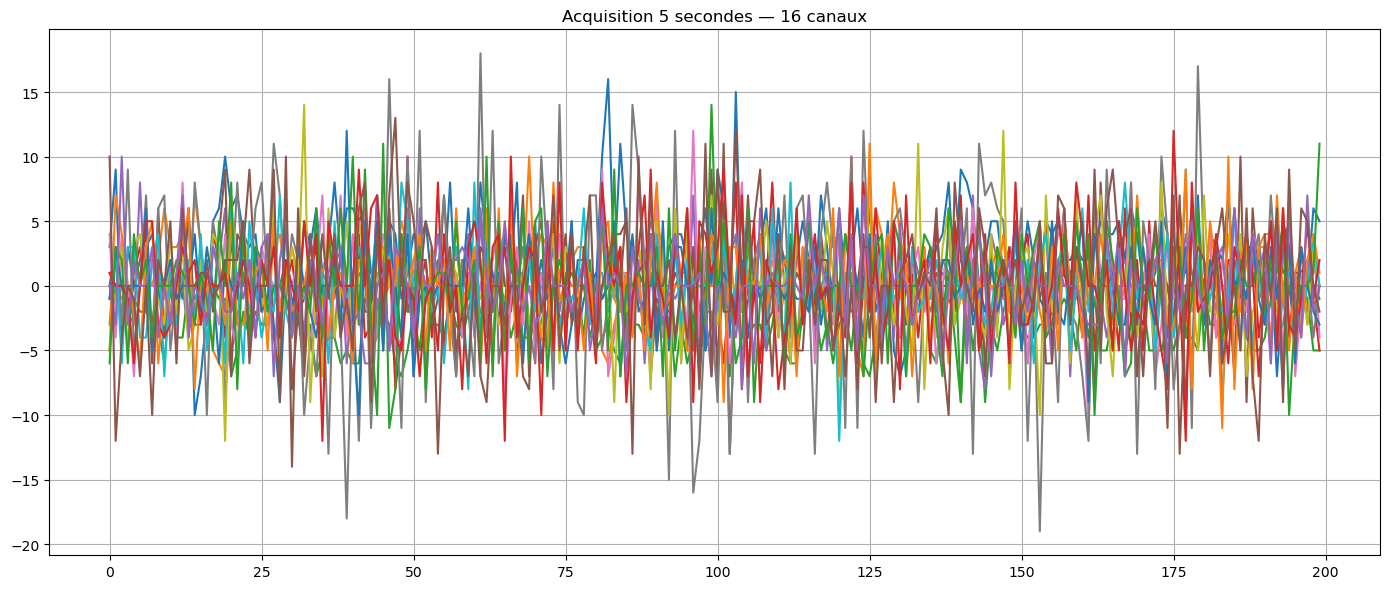

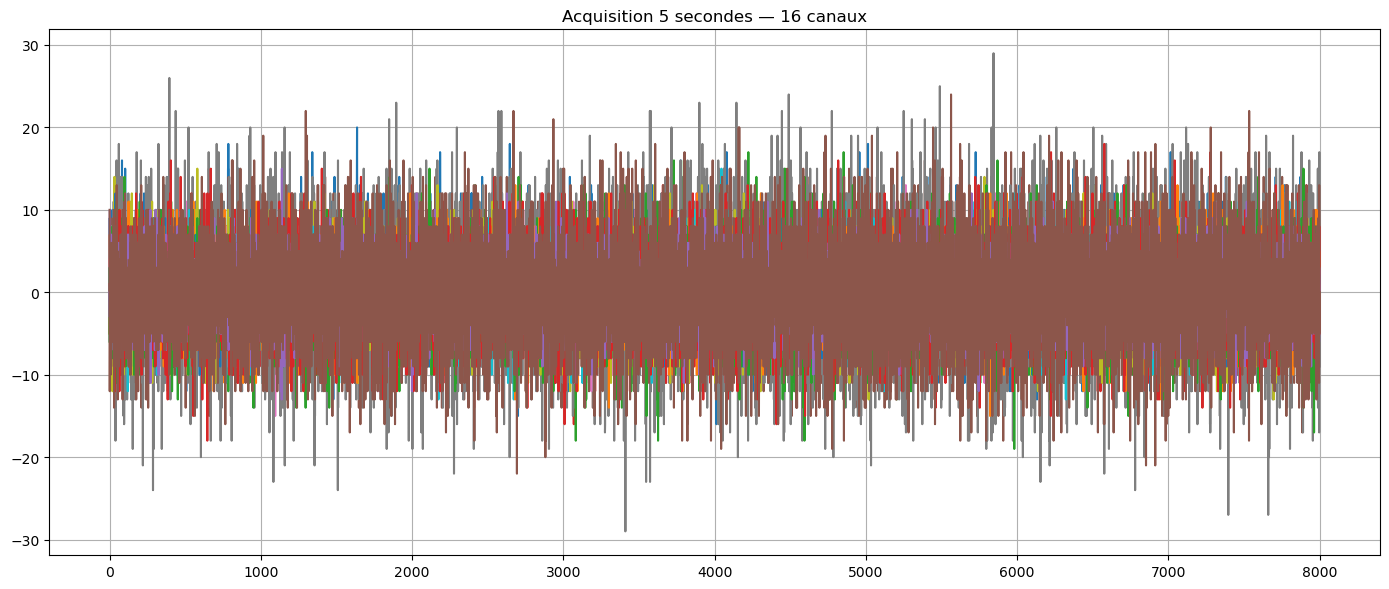

In [ ]:
import socket
import time
import struct
import numpy as np
import matplotlib.pyplot as plt

# ---- PARAMÈTRES / PARAMETERS ----
N_CHANNELS = 16
SAMPLE_RATE = 8000        # 8 kHz
DURATION = 1              # 1 secondes
TOTAL_FRAMES = SAMPLE_RATE * DURATION

# Buffer : 16 canaux × 10 000 frames = 160 000 points / 16 channels × 10,000 frames = 160,000 points
buffer = np.zeros((N_CHANNELS, TOTAL_FRAMES), dtype=np.int32)
write_index = 0

# ---- CONFIG UDP / UDP CONFIG ----
UDP_IP = "0.0.0.0"
UDP_PORT = 55151

sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
sock.bind((UDP_IP, UDP_PORT))
sock.settimeout(1.0)

print(f"📡 En écoute sur UDP {UDP_IP}:{UDP_PORT} ... (5 secondes d'enregistrement)")

start_time = time.time()

try:
    while write_index < TOTAL_FRAMES:
        try:
            data, addr = sock.recvfrom(4096)
            packet_len = len(data)

            # Nombre de frames dans ce paquet / Number of frames in this packet
            num_frames = packet_len // (2 * N_CHANNELS)
            offset = 0

            for _ in range(num_frames):
                if write_index >= TOTAL_FRAMES:
                    break

                # Lire une frame = 16 échantillons uint16 / Read one frame = 16 uint16 samples
                uvals = struct.unpack_from(f"{N_CHANNELS}H", data, offset)
                offset += N_CHANNELS * 2

                # conversion centrée / centered conversion
                samples = np.array(uvals, dtype=np.int32) - 32768
                samples = 0.195 * samples

                # stocker dans le buffer / store in buffer
                buffer[:, write_index] = samples
                write_index += 1

        except socket.timeout:
            print("⚠️ Timeout UDP — le STM32 envoie-t-il bien des paquets ?")
            continue

except KeyboardInterrupt:
    print("\nArrêt manuel.")

finally:
    sock.close()

end_time = time.time()
elapsed = end_time - start_time
expected = DURATION
print("✔️ Acquisition terminée.")
print(f"⏱️ Durée mesurée pour l'acquisition : {elapsed:.3f} s (attendu : {expected:.3f} s, écart : {elapsed-expected:+.3f} s)")

# ---- PLOT FINAL / FINAL PLOT ----
plt.figure(figsize=(14, 6))
for ch in range(N_CHANNELS):
    plt.plot(buffer[ch][0:200], label=f"ch {ch}")


plt.title("Acquisition 5 secondes — 16 canaux")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- PLOT FINAL / FINAL PLOT ----
plt.figure(figsize=(14, 6))
for ch in range(N_CHANNELS):
    plt.plot(buffer[ch], label=f"ch {ch}")

plt.title("Acquisition 5 secondes — 16 canaux")
plt.grid(True)
plt.tight_layout()
plt.show()


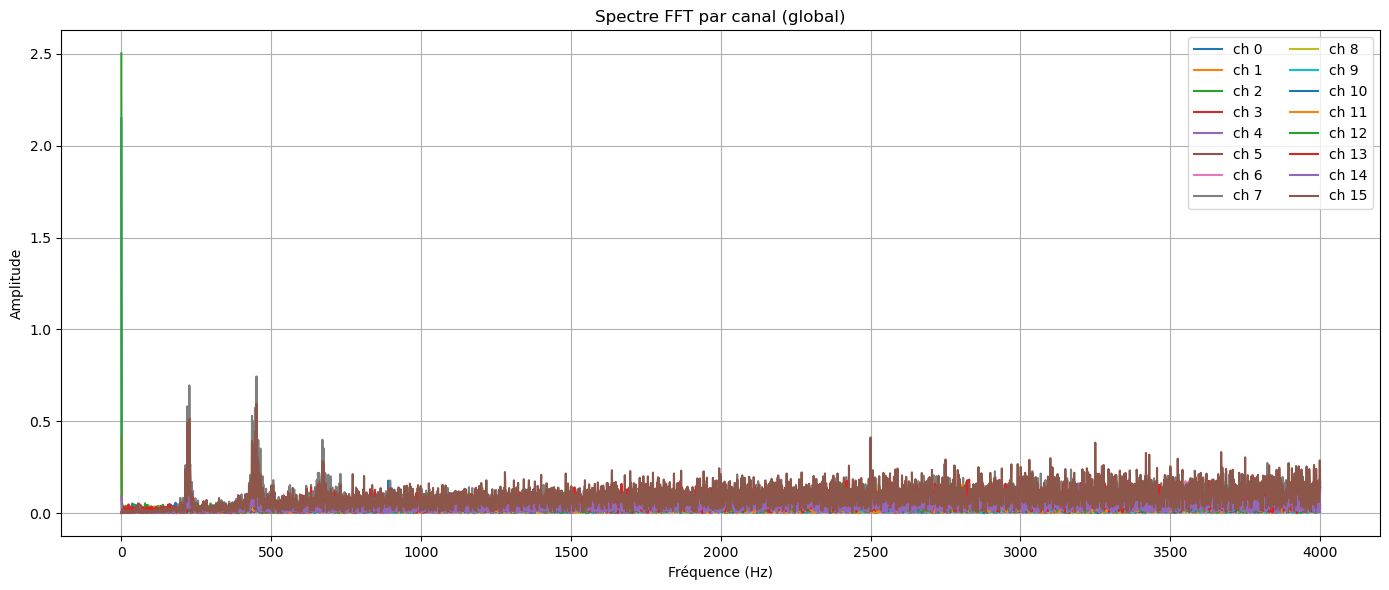

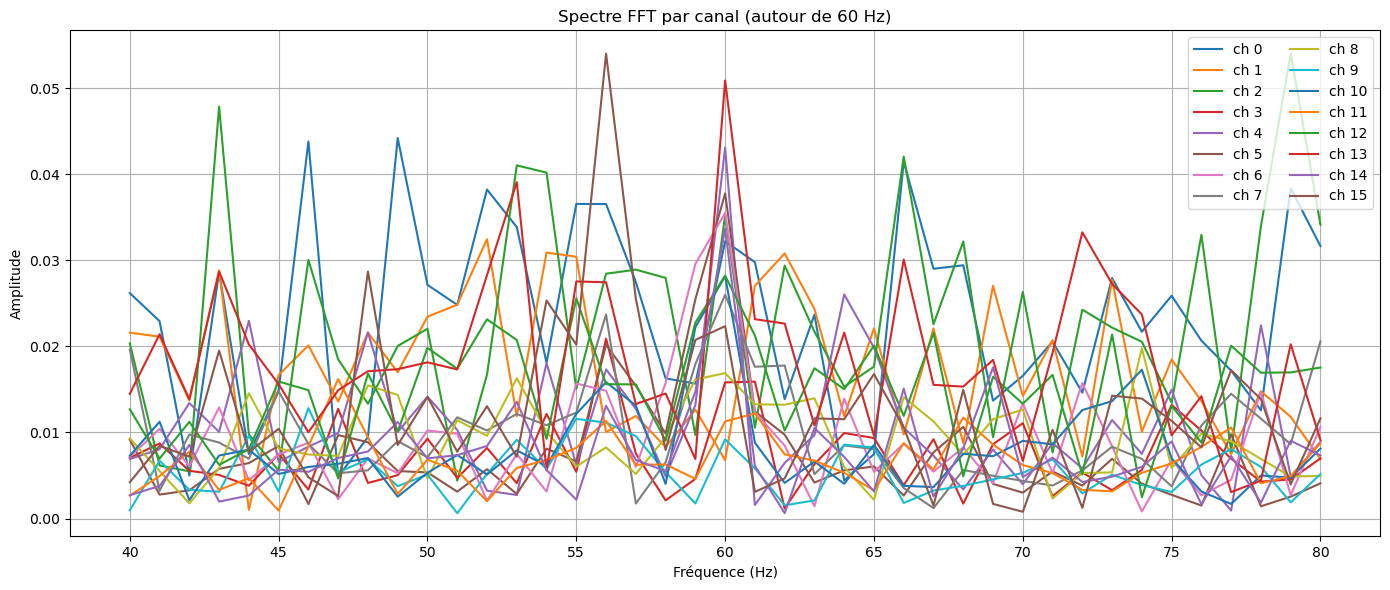

In [ ]:
fs = 8000  # Fréquence d'échantillonnage en Hz / Sampling frequency in Hz
N = buffer.shape[1]  # nombre d'échantillons / number of samples
freqs = np.fft.rfftfreq(N, 1/fs)

fft_mags = []  # stockera toutes les FFT pour chaque canal / will hold all FFTs for each channel

for ch in range(N_CHANNELS):
    signal = buffer[ch]
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_mags.append(fft_mag)

# Plot global : toutes les FFT sur le même graphique, tout le spectre / Global plot: all FFTs on same graph, full spectrum
plt.figure(figsize=(14, 6))
for ch in range(N_CHANNELS):
    plt.plot(freqs, fft_mags[ch], label=f'ch {ch}')
plt.title("Spectre FFT par canal (global)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

# Plot zoom autour de 60Hz (disons entre 40Hz et 80Hz) / Zoom plot around 60Hz (e.g. 40Hz to 80Hz)
plt.figure(figsize=(14, 6))
zoom_min = 40
zoom_max = 80
mask = (freqs >= zoom_min) & (freqs <= zoom_max)
for ch in range(N_CHANNELS):
    plt.plot(freqs[mask], fft_mags[ch][mask], label=f'ch {ch}')
plt.title("Spectre FFT par canal (autour de 60 Hz)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

stats = []

for ch in range(N_CHANNELS):
    sig = buffer[ch]
    rms = np.sqrt(np.mean(sig**2))
    std = np.std(sig)
    ptp = np.ptp(sig)
    stats.append([ch, rms, std, ptp])

df_stats = pd.DataFrame(stats, columns=["Canal", "RMS", "STD", "P2P"])
df_stats


,Canal,RMS,STD,P2P
0,0,2.979650,2.842273,32
1,1,2.011172,1.589602,13
2,2,2.746964,1.724209,13
3,3,3.137545,3.137545,30
4,4,3.399982,3.399982,30
5,5,2.881872,2.881866,28
6,6,2.753101,2.753100,31
7,7,2.778410,2.778410,24
8,8,2.881384,2.881378,24
9,9,2.865506,2.865504,24


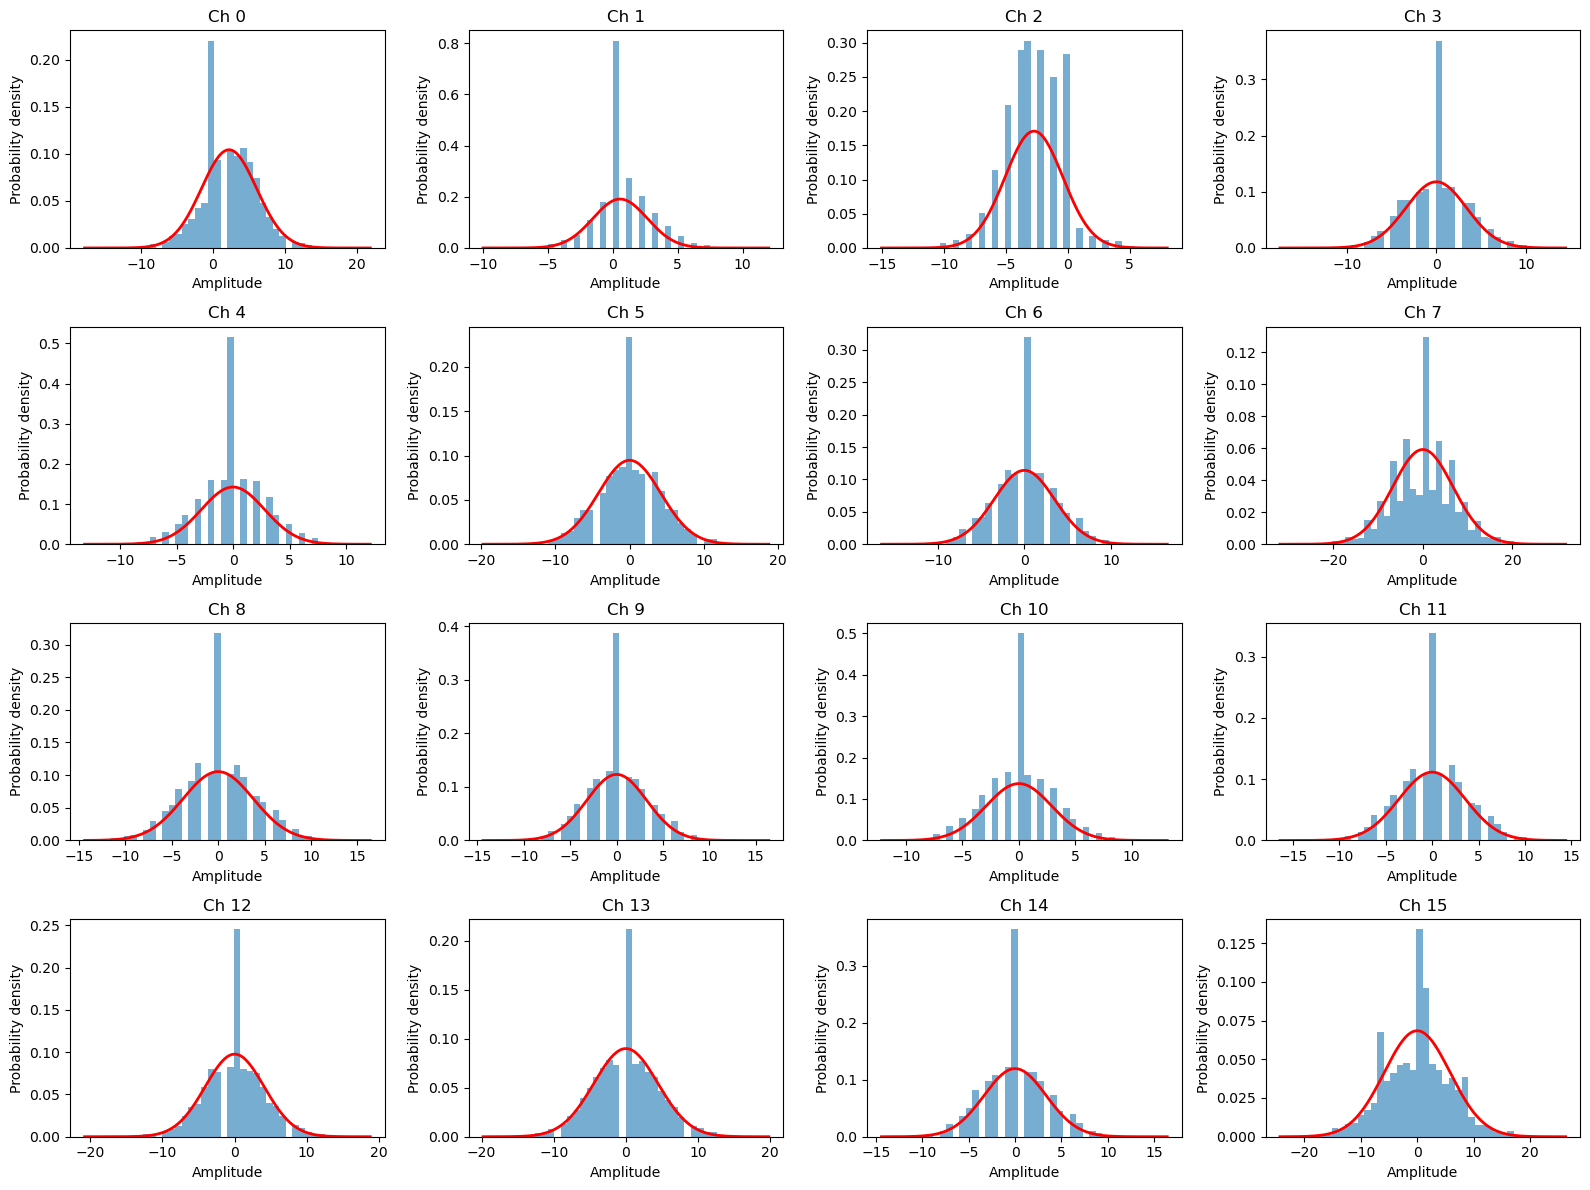

In [38]:
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(16,12))
for ch in range(N_CHANNELS):
    plt.subplot(4,4,ch+1)
    sig = buffer[ch]
    mu, sigma = norm.fit(sig)
    plt.hist(sig, bins=40, density=True, alpha=0.6)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 200)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
    plt.xlabel("Amplitude")
    plt.ylabel("Probability density")
    plt.title(f"Ch {ch}")
plt.tight_layout()
plt.show()


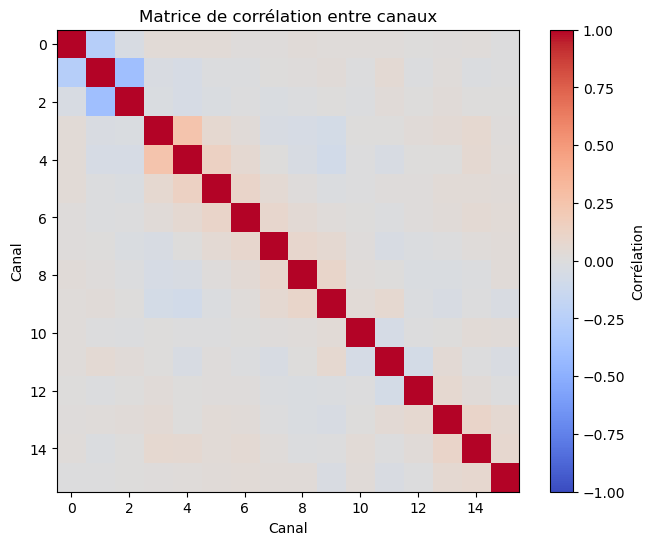

In [ ]:
corr = np.corrcoef(buffer)
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Corrélation")
plt.title("Matrice de corrélation entre canaux")
plt.xlabel("Canal")
plt.ylabel("Canal")
plt.show()


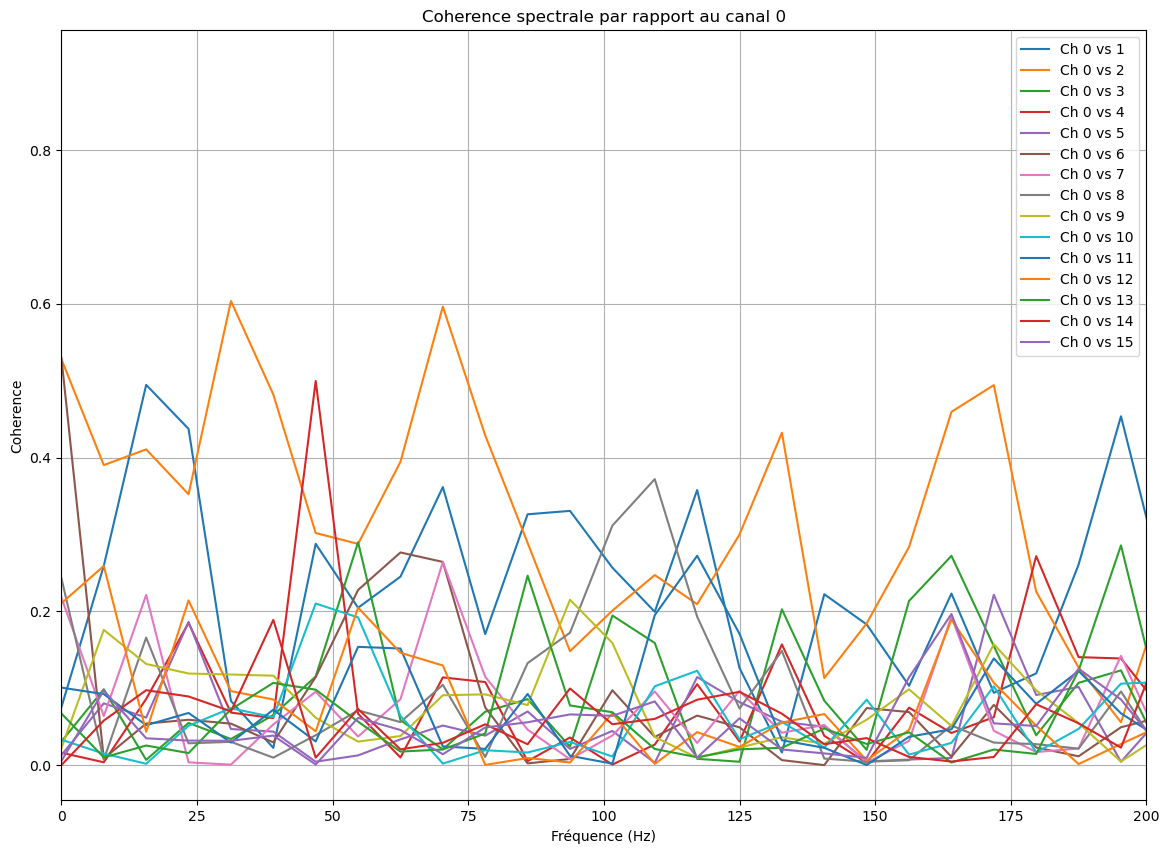

In [ ]:
from scipy.signal import coherence

# On choisit la cohérence par rapport au canal 0 / Coherence is computed relative to channel 0
ref_ch = 0
f, _ = coherence(buffer[0], buffer[1], fs=fs)

plt.figure(figsize=(14,10))
for ch in range(N_CHANNELS):
    if ch != ref_ch:
        f, Cxy = coherence(buffer[ref_ch], buffer[ch], fs=fs, nperseg=2048)
        plt.plot(f, Cxy, label=f"Ch 0 vs {ch}")

plt.xlim([0, 200])  # utile pour le bruit électrique / useful for electrical noise
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Coherence")
plt.grid(True)
plt.legend()
plt.title("Coherence spectrale par rapport au canal 0")
plt.show()


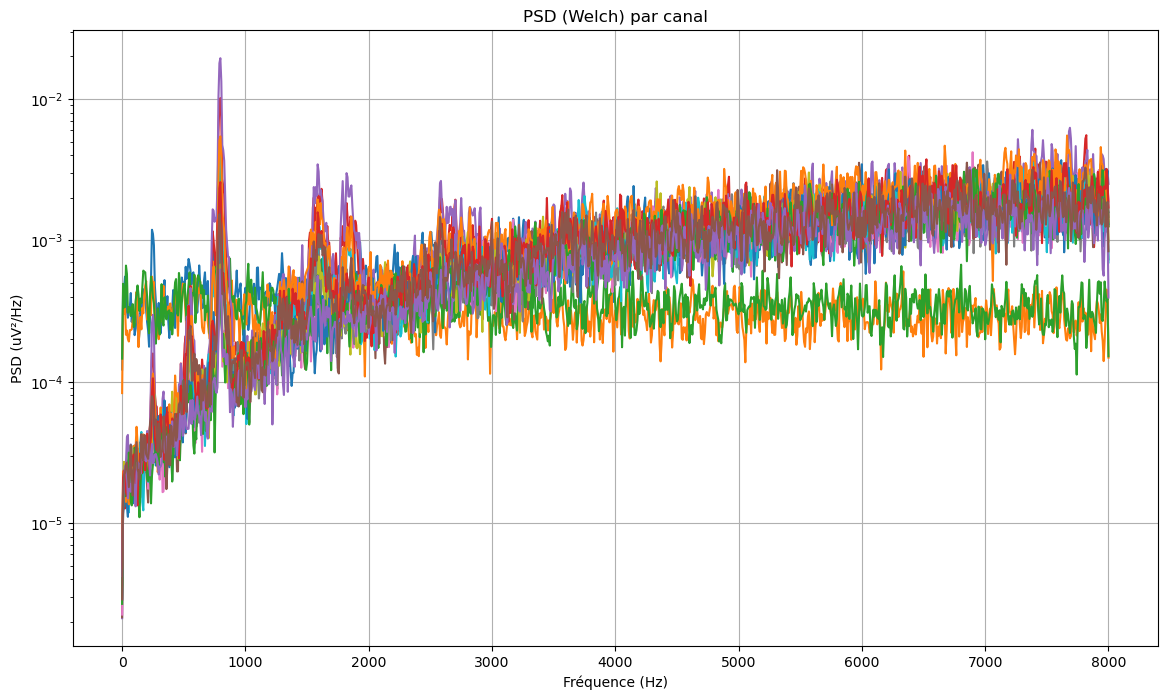

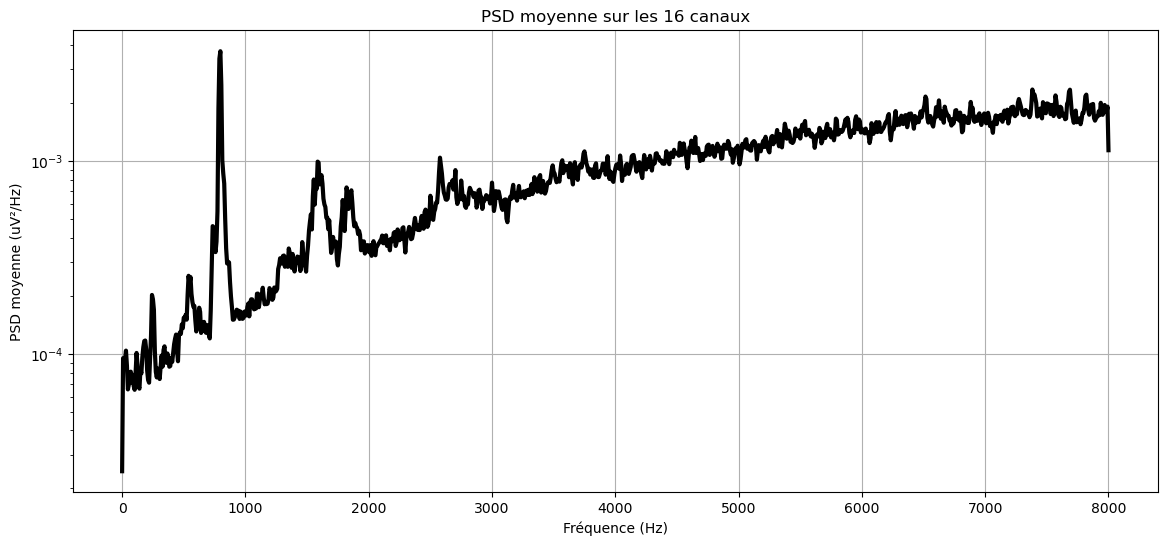

In [ ]:
from scipy.signal import welch

plt.figure(figsize=(14,8))

psds = []
for ch in range(N_CHANNELS):
    f, Pxx = welch(buffer[ch], fs=fs, nperseg=2048)
    psds.append(Pxx)
    plt.semilogy(f, Pxx)
    
plt.title("PSD (Welch) par canal")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (uV²/Hz)")
plt.grid(True)
plt.show()

# PSD moyenne / Average PSD
psd_mean = np.mean(np.array(psds), axis=0)

plt.figure(figsize=(14,6))
plt.semilogy(f, psd_mean, 'k', linewidth=3)
plt.title("PSD moyenne sur les 16 canaux")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD moyenne (uV²/Hz)")
plt.grid(True)
plt.show()


In [ ]:
bands = {
    "LFP (0–300 Hz)": (0, 300),
    "Spikes (300–3000 Hz)": (300, 3000)
}

noise_bands = []

psds = []
for ch in range(N_CHANNELS):
    f, Pxx = welch(buffer[ch], fs=fs, nperseg=2048)
    psds.append(Pxx)
    
psds = np.array(psds)

for name, (fmin, fmax) in bands.items():
    mask = (f >= fmin) & (f <= fmax)
    # Intégration PSD -> bruit RMS / PSD integration -> RMS noise
    band_rms = np.sqrt(np.trapz(psds[:,mask], f[mask], axis=1))
    noise_bands.append([name] + list(band_rms))

df_noise = pd.DataFrame(noise_bands, columns=["Bande"] + [f"Ch{ch}" for ch in range(N_CHANNELS)])
df_noise


,Bande,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9,Ch10,Ch11,Ch12,Ch13,Ch14,Ch15
0,LFP (0–300 Hz),0.342982,0.300067,0.338270,0.110624,0.124038,0.087808,0.087831,0.092058,0.090366,0.094774,0.091175,0.101885,0.082309,0.098064,0.085769,0.100658
1,Spikes (300–3000 Hz),1.244017,0.972067,1.062684,1.341889,1.564742,0.937123,0.909903,0.933499,0.920808,1.068592,0.929468,1.250043,0.863667,1.066886,0.821718,1.010440


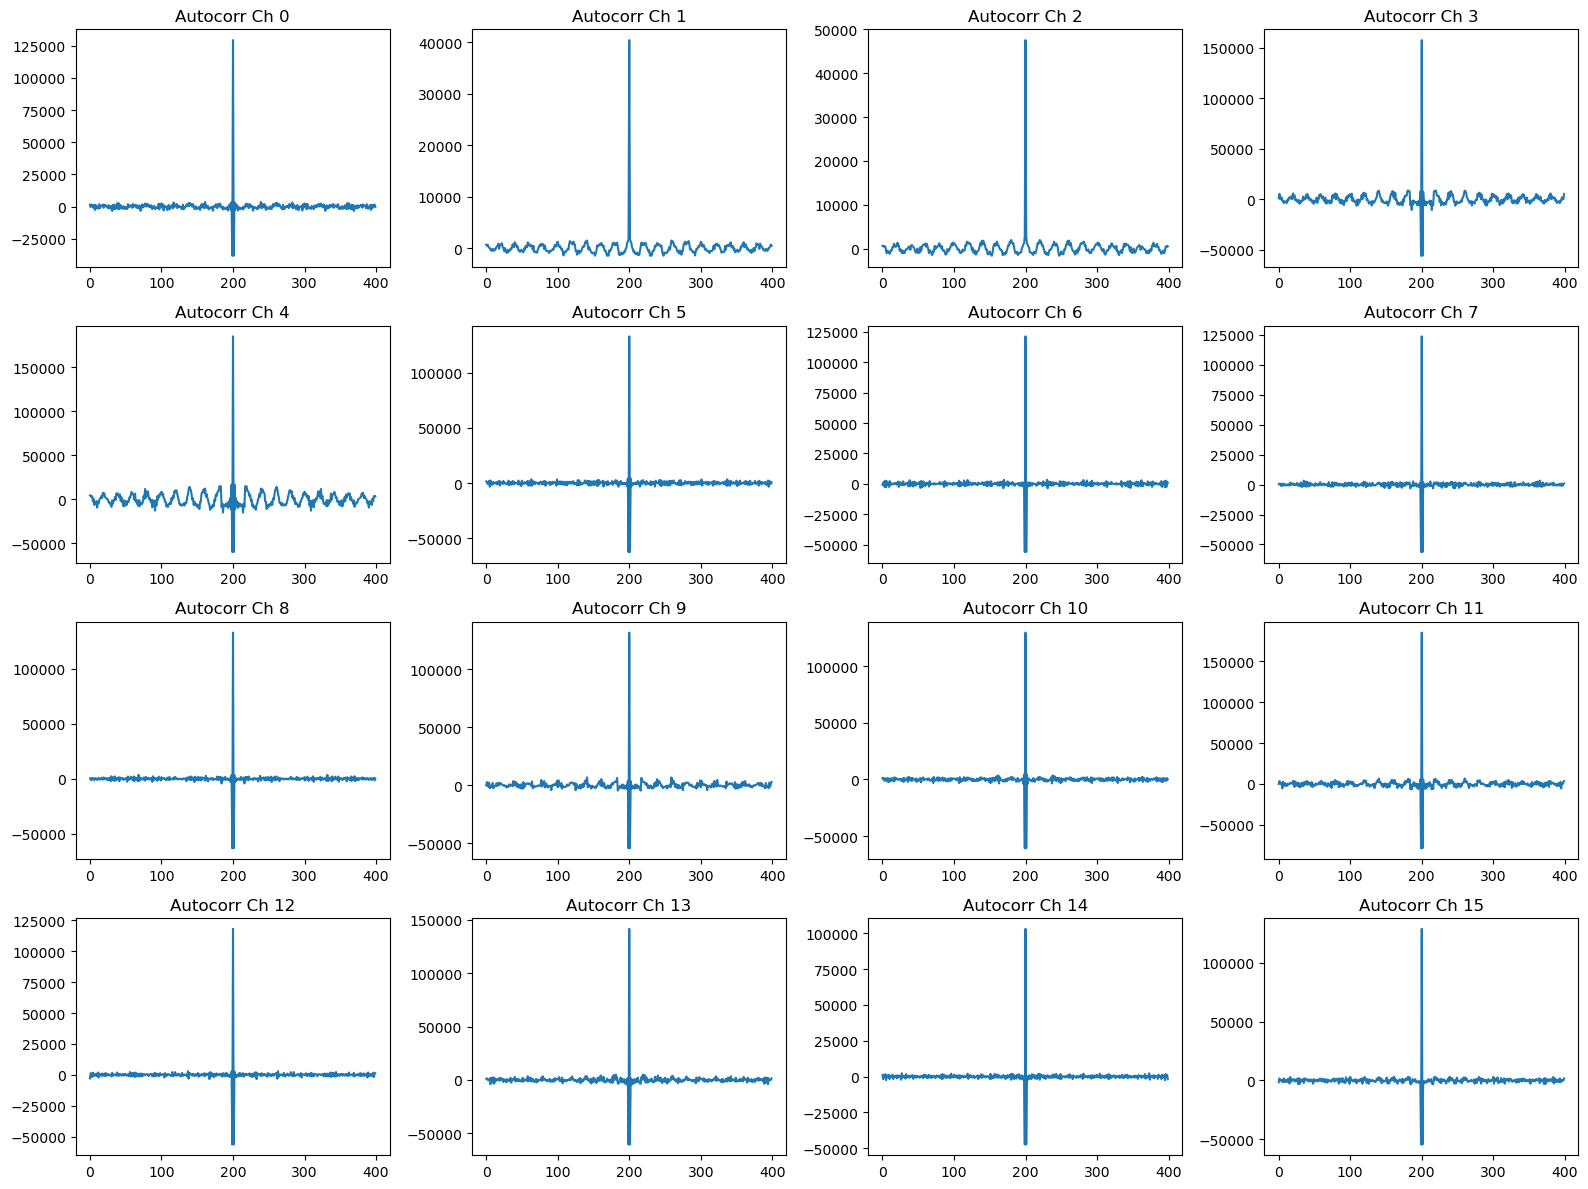

In [ ]:
from scipy.signal import correlate

plt.figure(figsize=(16,12))
for ch in range(N_CHANNELS):
    plt.subplot(4,4,ch+1)
    sig = buffer[ch] - np.mean(buffer[ch])
    ac = correlate(sig, sig, mode='full')
    mid = len(ac)//2
    plt.plot(ac[mid-200:mid+200])
    plt.title(f"Autocorr Ch {ch}")
plt.tight_layout()
plt.show()


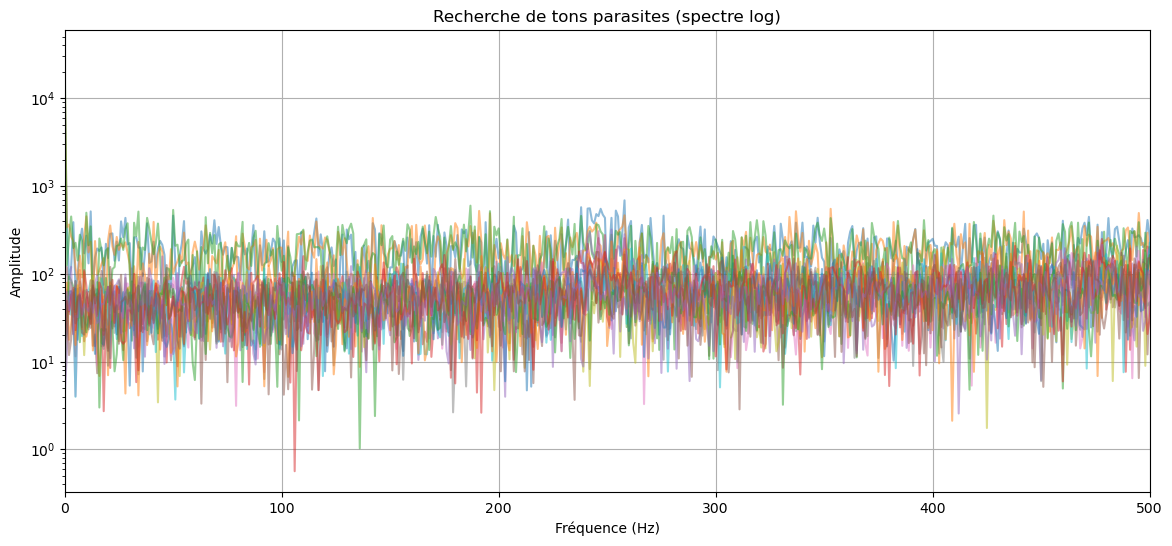

In [ ]:
plt.figure(figsize=(14,6))

for ch in range(N_CHANNELS):
    fft_vals = np.fft.rfft(buffer[ch])
    fft_mag = np.abs(fft_vals)
    plt.plot(freqs, fft_mag, alpha=0.5)

plt.yscale('log')
plt.xlim(0, 500)
plt.title("Recherche de tons parasites (spectre log)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [ ]:
# Exemple si tu sais l'échelle de ton ADC : / Example if you know your ADC scale:
Vref = 2.5
bits = 24
LSB = Vref / (2**bits)

results = []
for ch in range(N_CHANNELS):
    sig = buffer[ch]
    mod_lsb = np.mod(sig, LSB)
    std_mod = np.std(mod_lsb)
    results.append([ch, std_mod])

pd.DataFrame(results, columns=["Canal", "Std(sig mod LSB)"])


,Canal,Std(sig mod LSB)
0,0,4.409077e-08
1,1,4.512321e-08
2,2,4.413640e-08
3,3,4.438329e-08
4,4,4.475327e-08
5,5,4.460497e-08
6,6,4.457580e-08
7,7,4.511665e-08
8,8,4.430214e-08
9,9,4.433272e-08
